# Invoke Fine-Tuned Document to JSON multi-modal model

This notebook demonstrates how to process documents using a deployed SageMaker endpoint. It shows how to:

1. Load and process images
2. Make requests to a SageMaker endpoint
3. Handle responses and extract information

## Prerequisites

Before running this notebook, ensure you have:

- AWS credentials configured
- Fine-tuned and deployed a model to a SageMaker endpoint [06_deploy_model_endpoint.ipynb](./06_deploy_model_endpoint.ipynb)
- Access to the document images

## Setup

First, let's install and import the required modules.

In [1]:
%pip install --quiet requests json2table


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import subprocess
from pathlib import Path
from IPython.display import display, JSON, Image as IPImage, HTML
from typing import Dict, Optional, Any, Union
import requests
from PIL import Image
import io
import base64
from json2table import convert
from utils.docdiff import get_pil_image,image_formatter

## Helpers
The following helper functions will help to process the input, output and invoke the endpoint. 

In [3]:
def display_results(image_path: str, response: Dict) -> None:
    """
    Display input image and extracted information side by side using flexbox layout.
    
    Args:
        image_path: Path to the input image
        response: Processed response from the endpoint
    """
    # Create display objects
    json_content = response.get("choices", [{}])[0].get("message", {}).get("content", {})

    if json_content:
        json_content = json.loads(json_content)
   
        html_table = convert(
            json_content, 
            table_attributes={"class": "table table-striped"}
        )
    else:
        html_table = "No content found in response"
   
    img_html = image_formatter(get_pil_image(image_path))

    html = f"""
    <div style="font-size: 24px; font-weight: bold; text-align: center; margin-bottom: 20px;">Invoice Details</div>
    <div style="display: flex; gap: 0px; align-items: flex-start;">
        <!-- Image Section -->
        <div style="flex: 1; text-align: center;">
            {img_html}
        </div>
    
        <!-- Table Section -->
        <div style="flex: 1; overflow-x: auto;">
           {html_table}
        </div>
    </div>
    """

    display(HTML(html))

In [4]:
def encode_image(image_path: Union[str, Path]) -> str:
    """
    Convert image to base64 string with proper MIME type prefix.
    
    Args:
        image_path: Path to the image file
        
    Returns:
        Base64 encoded image string with data URI prefix
        
    """
    try:
        with Image.open(image_path) as image:
            buffered = io.BytesIO()
            image.save(buffered, format=image.format)
            mime_type = Image.MIME[image.format]
            img_str = f"data:{mime_type};base64,{base64.b64encode(buffered.getvalue()).decode()}"
            return img_str
    except Exception as e:
        print(f"Error loading image: {str(e)}")
        return None

In [5]:
def load_schema(schema_path: Optional[str]) -> Dict[str, Any]:
    """
    Load JSON schema from file.

    Args:
        schema_path: Path to the json schema file
    
    Returns:
        Loaded JSON schema
    """
    if schema_path:
        try:
            with open(schema_path, 'r') as f:
                json_schema = json.load(f)
                return json_schema
            print("Schema loaded successfully")
        except Exception as e:
            print(f"Error loading schema: {str(e)}")
    
    return None

In [6]:
def prepare_payload(model_name: str, image_base64: Optional[str], properties_to_extract: str = "", guided_decoding = None) -> Dict[str, Any]:
    """
    Prepare the request payload.
    
    Args:
        model_name: the model to invoke
        image_base64: Optional Base64 encoded image
        properties_to_extract: Optional JSON key names to extract. 
                                They will be added to prompt.
        schema: Optional vllm structured output configuration 
        
    Returns:
        Request payload dictionary
    """
    content = []

    content.append({
        "type": "text",
        "text": "Document pages: "
    })
    
    if image_base64:
        content.append({
            "type": "image_url",
            "image_url": {"url":image_base64}
        })

    
    content.append({
        "type": "text",
        "text": f"Process all document pages and extract the following information in JSON format: {properties_to_extract}"
    })

    
    
    payload = {
        "model": model_name,
        "messages": [
            {
                "role": "system", 
                "content": "You are a document processing expert and assistant."
            },
            {
                "role": "user",
                "content": content
            }
        ],
        "extra_body": guided_decoding
    }

    # if schema:
    #     payload["guided_json"] = schema

    return payload

    

In [7]:
def get_identity_token() -> str:
    """
    Lay Google identity token hien tai (dung de goi Cloud Run service
    dang chay voi --no-allow-unauthenticated).
    Yeu cau: da chay  san trong moi truong chay notebook.
    """
    result = subprocess.run(
        "gcloud auth print-identity-token",
        shell=True,
        capture_output=True, 
        text=True, 
        check=True
    )
    return result.stdout.strip()


def invoke_endpoint(endpoint_url: str, payload: Dict[str, Any], timeout: int = 120) -> Dict[str, Any]:
    """
    Process a document by calling the Cloud Run vLLM service via REST
    (OpenAI-compatible API). Replaces the original SageMaker
    runtime.invoke_endpoint() call.

    Args:
        endpoint_url: full Cloud Run service URL, e.g.
                      "https://vllm-serve-bill-xxxxx-as.a.run.app"
                      (no need to include /v1/chat/completions, added automatically)
        payload: the input to send to the endpoint (same shape as before)

    Returns:
        Processed document data (OpenAI chat completion JSON)
    """
    url = f"{endpoint_url.rstrip('/')}/v1/chat/completions"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {get_identity_token()}",
    }

    print(f"Invoking {url}")
    response = requests.post(url, headers=headers, json=payload, timeout=timeout)
    response.raise_for_status()
    return response.json()

## Configuration
Replace the values below.

In [8]:
# Lay URL bang lenh:
#   gcloud run services describe vllm-serve-bill --region asia-southeast1 \
#     --project first-orc-chien --format 'value(status.url)'
ENDPOINT_URL = "https://vllm-serve-identity-73397202200.asia-southeast1.run.app"  # Thay bang URL that
MODEL_NAME = "document-identity"  # Khop SM_VLLM_SERVED_MODEL_NAME trong deploy.env

Optionally you can use structured output / constrained decoding to guide the models response structure, for example to only allow valid JSON:

In [9]:
SCHEMA_PATH = None

In [10]:
guided_decoding = None

In [11]:
properties_to_extract = """
  "document_type": "",
  "provider_name": "",
  "provider_abn": "",
  "account_holder_name": "",
  "account_number": "",
  "nmi": "",
  "service_address_street": "",
  "service_address_suburb": "",
  "service_address_state": "",
  "service_address_postcode": "",
  "bill_issue_date": "",
  "bill_due_date": "",
  "billing_period_start": "",
  "billing_period_end": "",
  "total_electricity_kwh": "",
  "average_daily_usage_kwh": "",
  "total_amount": "",
  "amount_due": ""
"""
# properties_to_extract = "AMOUNT_DUE, BILL_TO, BUYER, CONDITIONS, DATE, DISCOUNT, DUE_DATE, GST(1%), GST(12%), GST(18%), GST(20%), GST(5%), GST(7%), GST(9%), GSTIN, GSTIN_BUYER, GSTIN_SELLER, INVOICE_INFO, LOGO, NOTE, NUMBER, PAYMENT_DETAILS, PO_NUMBER, SELLER_ADDRESS, SELLER_EMAIL, SELLER_NAME, SELLER_SITE, SEND_TO, SUB_TOTAL, TABLE, TAX, TITLE, TOTAL, TOTAL_WORDS"

## Prepare Input

In [12]:
if SCHEMA_PATH:
    schema = load_schema(SCHEMA_PATH)
    guided_decoding =  {"guided_json": schema}
    properties_to_extract = ", ".join(schema.get("required", []))

In [13]:
IMAGE_PATH = "data//electric_bill//images//agl_bill_00009_page000.png"
image_base64 = encode_image(IMAGE_PATH)
    
payload = prepare_payload(MODEL_NAME, image_base64, properties_to_extract, guided_decoding)

## Invoke Endpoint

In [14]:
response = invoke_endpoint(ENDPOINT_URL, payload, timeout=300)

Invoking https://vllm-serve-identity-73397202200.asia-southeast1.run.app/v1/chat/completions


Next, let's look at the raw response.

## Inspect Response

In [15]:
JSON(response, expanded=True)

<IPython.core.display.JSON object>

Next, let's show the image of the document and the extracted JSON side by side:

document_type,Electricity Bill
provider_name,agl
provider_abn,88 090 538 337
account_holder_name,Evan McCormick
account_number,5363 946 708
nmi,41714828847
service_address_street,2704 Samantha Ground
service_address_suburb,PARRAMATTA
service_address_state,NSW
service_address_postcode,2150
bill_issue_date,19 February 2025

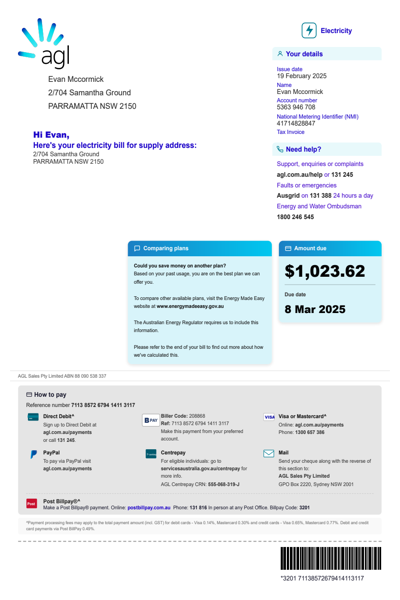

In [16]:
display_results(IMAGE_PATH, response)

## Conclusion

We received a structured JSON output from the fine-tuned and deployed endpoint by sending the image of a document and the desired target schema.